# Fine-tuning médico com LoRA

In [1]:
# Dependências fixadas para reprodutibilidade do experimento.
!pip install -q \
  "transformers==5.14.1" \
  "trl==1.9.0" \
  "peft==0.19.1" \
  "bitsandbytes==0.50.0" \
  "datasets==5.0.1" \
  "accelerate==1.14.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 91.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 885.0/885.0 kB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 89.3 MB/s eta 0:00:00


In [ ]:
# Imports e diagnóstico do ambiente
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import json, math, time, random, shutil, gc
from collections import Counter

import numpy as np
import torch
import transformers, datasets, peft, trl
import bitsandbytes as bnb

from datasets import Dataset, load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from transformers import EarlyStoppingCallback
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTConfig, SFTTrainer

for _m in (torch, transformers, datasets, peft, trl, bnb):
    print(f"{_m.__name__:16s} {_m.__version__}")

if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU CUDA não encontrada. No Colab: "
        "Ambiente de execução > Alterar tipo de ambiente de execução > GPU."
    )

print("GPU:", torch.cuda.get_device_name(0),
      "| capability:", torch.cuda.get_device_capability(),
      "| VRAM:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "GB")

torch            2.11.0+cu128
transformers     5.14.1
datasets         5.0.1
peft             0.19.1
trl              1.9.0
bitsandbytes     0.50.0
GPU: Tesla T4 | capability: (7, 5) | VRAM: 15.6 GB


## 1. Configuração do experimento

Para testar outro modelo, em princípio basta trocar `MODEL_ID`.

`MODO_TESTE=True` limita os passos para validar se o pipeline roda.
No treino final use `MODO_TESTE=False`.

In [ ]:
# ----------------------------
# CONFIGURAÇÃO CENTRAL
# ----------------------------

MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"
TRUST_REMOTE_CODE = False

MODO_TESTE = False
SEED = 42                 # idêntico ao SEED do preprocessamento_dataset.ipynb

USAR_4BIT = False

# MAX_LENGTH é fallback; o valor efetivo vem do preprocessamento (seção 3).
MAX_LENGTH = 512

# LoRA — r maior compra capacidade de decorar estilo, que é o que a métrica mede.
LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05
LORA_TARGET_MODULES = ["q_proj","k_proj","v_proj","o_proj"]

# Treinamento
BATCH_SIZE = 4
GRAD_ACCUM_STEPS = 4
EVAL_BATCH_SIZE = 2 
LEARNING_RATE = 1.0e-4
EPOCHS_TREINO_FINAL = 2
MAX_STEPS_TESTE = 20
EARLY_STOPPING_PATIENCE = 1

BASE_DRIVE = "/content/drive/MyDrive/Colab Notebooks/FIAP - Tech 3"

# Saída do preprocessamento
PREPROCESSED_DIR = f"{BASE_DRIVE}/dataset_preprocessado_v3"
ADAPTER_DIR = f"{BASE_DRIVE}/assistente-medico-v3-adapter"

# Checkpoints em disco LOCAL, não no Drive
RUN_ID = f"{'teste' if MODO_TESTE else 'final'}-{time.strftime('%Y%m%d-%H%M')}"
OUTPUT_DIR = f"/content/ckpt/{RUN_ID}"

SAVE_TOTAL_LIMIT = 1
N_EVAL = 400              # exemplos de validação por avaliação

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

print("RUN_ID:    ", RUN_ID)
print("OUTPUT_DIR:", OUTPUT_DIR)

RUN_ID:     final-20260913-1346
OUTPUT_DIR: /content/ckpt/final-20260913-1346


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Modelo, tokenizer e LoRA

Na T4 (sm_75) não há bf16 real nem FlashAttention-2, então o treino roda em fp16
com `sdpa`.

O `target_modules="all-linear"` mantém a configuração próxima do LoRA clássico e
evita amarrar o notebook aos nomes internos de uma arquitetura específica.

In [5]:
major, _ = torch.cuda.get_device_capability()
USE_BF16 = major >= 8                     # T4 -> False
COMPUTE_DTYPE = torch.bfloat16 if USE_BF16 else torch.float16
print("Compute dtype:", COMPUTE_DTYPE, "| 4-bit:", USAR_4BIT)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=TRUST_REMOTE_CODE)
if tokenizer.pad_token_id is None:
    if tokenizer.eos_token_id is None:
        raise ValueError("Tokenizer sem pad_token e sem eos_token.")
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

kwargs_modelo = dict(
    device_map={"": 0},
    dtype=COMPUTE_DTYPE,
    attn_implementation="sdpa",           # T4 não suporta FlashAttention-2
    trust_remote_code=TRUST_REMOTE_CODE,
)
if USAR_4BIT:
    kwargs_modelo["quantization_config"] = BitsAndBytesConfig(
        load_in_4bit=True, bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4", bnb_4bit_compute_dtype=COMPUTE_DTYPE,
    )

modelo = AutoModelForCausalLM.from_pretrained(MODEL_ID, **kwargs_modelo)
modelo.config.use_cache = False
modelo.config.pad_token_id = tokenizer.pad_token_id

print("VRAM do modelo:", round(torch.cuda.memory_allocated() / 1e9, 2), "GB")

Compute dtype: torch.float16 | 4-bit: False


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

VRAM do modelo: 6.17 GB


In [ ]:
import sys, peft.import_utils as _piu
_piu.is_torchao_available = lambda: False
for _m in list(sys.modules.values()):
    if getattr(_m, "__name__", "").startswith("peft") and hasattr(_m, "is_torchao_available"):
        _m.is_torchao_available = lambda: False

if USAR_4BIT:
    modelo = prepare_model_for_kbit_training(modelo, use_gradient_checkpointing=True)
else:
    # necessário caso gradient_checkpointing seja religado por OOM
    modelo.enable_input_require_grads()

peft_config = LoraConfig(
    r=LORA_R, lora_alpha=LORA_ALPHA, lora_dropout=LORA_DROPOUT,
    bias="none", task_type="CAUSAL_LM", target_modules=LORA_TARGET_MODULES,
)
modelo_peft = get_peft_model(modelo, peft_config)

for _n, _p in modelo_peft.named_parameters():
    if _p.requires_grad:
        _p.data = _p.data.float()

print("dtypes treináveis:", Counter(
    str(p.dtype) for p in modelo_peft.parameters() if p.requires_grad))
modelo_peft.print_trainable_parameters()

dtypes treináveis: Counter({'torch.float32': 288})
trainable params: 7,372,800 || all params: 3,093,311,488 || trainable%: 0.2383


## 3. Dataset

Consome os artefatos do `preprocessamento_dataset.ipynb`. Aqui não se refaz
mapeamento de schema, limpeza nem split.

Schema de cada linha:

- `instrucao` — o system prompt curto e fixo (**o mesmo para todas as linhas**);
- `entrada` — a pergunta;
- `saida` — a resposta;
- `n_tokens` — comprimento, usado pelo sampler agrupado da seção 6.

`condition`, `medical_specialty` e `question_type` continuam nas colunas como
rastreabilidade, mas **não entram mais no prompt**: são metadados do registro que
não existem quando um usuário faz uma pergunta de verdade.

In [7]:
CAMINHO_TRAIN = os.path.join(PREPROCESSED_DIR, "train.jsonl")
CAMINHO_EVAL  = os.path.join(PREPROCESSED_DIR, "validation.jsonl")
CAMINHO_TEST  = os.path.join(PREPROCESSED_DIR, "test.jsonl")
CAMINHO_META  = os.path.join(PREPROCESSED_DIR, "preprocessing_metadata.json")

COLUNAS_OBRIGATORIAS = {"instrucao", "entrada", "saida"}

def _carregar(caminho):
    if not os.path.exists(caminho) or os.path.getsize(caminho) == 0:
        return None
    ds = load_dataset("json", data_files=caminho, split="train")
    return ds if len(ds) > 0 else None

train_raw = _carregar(CAMINHO_TRAIN)
eval_raw  = _carregar(CAMINHO_EVAL)
test_raw  = _carregar(CAMINHO_TEST)

if train_raw is None:
    raise FileNotFoundError(
        f"Nada em {PREPROCESSED_DIR}. Rode o preprocessamento_dataset.ipynb (v3) antes."
    )

def _validar(ds, nome, amostra=200):
    if ds is None:
        return
    faltando = COLUNAS_OBRIGATORIAS - set(ds.column_names)
    if faltando:
        raise ValueError(f"Split '{nome}' sem as colunas: {sorted(faltando)}")
    for i in range(min(len(ds), amostra)):
        for col in COLUNAS_OBRIGATORIAS:
            v = ds[i][col]
            if not isinstance(v, str) or not v.strip():
                raise ValueError(f"Split '{nome}', exemplo {i}: coluna '{col}' vazia.")

for _nome, _ds in [("train", train_raw), ("validation", eval_raw), ("test", test_raw)]:
    _validar(_ds, _nome)

with open(CAMINHO_META, encoding="utf-8") as f:
    META_PREP = json.load(f)

MAX_LENGTH = int(META_PREP["max_length_sugerido"])
SYSTEM_PROMPT = META_PREP["system_prompt"]

# O prompt de treino e o de inferência TÊM que ser a mesma string. Treinar numa
# distribuição e gerar em outra infla a validação e degrada a geração real.
assert train_raw[0]["instrucao"] == SYSTEM_PROMPT, \
    "A coluna 'instrucao' não bate com o system_prompt do metadata."

print(f"Treino: {len(train_raw)} | Validação: {len(eval_raw or [])} | Teste: {len(test_raw or [])}")
print(f"MAX_LENGTH: {MAX_LENGTH} | descarte na limpeza: {META_PREP['limpeza']['taxa_descarte']:.1%}")
print(f"tokens/exemplo: {META_PREP['tokens']['media_total']} "
      f"| com gradiente: {META_PREP['tokens']['pct_com_gradiente']}%")
print("\nSYSTEM_PROMPT:", SYSTEM_PROMPT)

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Treino: 3896 | Validação: 487 | Teste: 487
MAX_LENGTH: 408 | descarte na limpeza: 51.3%
tokens/exemplo: 212.9 | com gradiente: 46.7%

SYSTEM_PROMPT: Você é um assistente médico de apoio. Responda em português, de forma objetiva e baseada em evidências, e não substitua a avaliação de um profissional de saúde.


## 4. Conversão para SFT

Idêntica à versão anterior — e é justamente por isso que ela agora está correta:
como `instrucao` já é o prompt curto e fixo, a mesma função produz um dataset
consistente sem nenhuma mudança aqui.

In [8]:
USA_CHAT_TEMPLATE = bool(getattr(tokenizer, "chat_template", None))
print("Tokenizer possui chat_template:", USA_CHAT_TEMPLATE)

def converter_para_sft(exemplo):
    if USA_CHAT_TEMPLATE:
        return {
            "prompt": [
                {"role": "system", "content": exemplo["instrucao"]},
                {"role": "user",   "content": exemplo["entrada"]},
            ],
            "completion": [
                {"role": "assistant", "content": exemplo["saida"]},
            ],
        }
    prompt = (f"### Sistema:\n{exemplo['instrucao']}\n\n"
              f"### Usuário:\n{exemplo['entrada']}\n\n"
              "### Assistente:\n")
    return {"prompt": prompt, "completion": exemplo["saida"]}

def _converter(ds):
    return None if ds is None else ds.map(converter_para_sft, remove_columns=ds.column_names)

# *_full nunca é reatribuído: trocar MODO_TESTE e re-rodar uma célula só não
# pode deixar o dataset reduzido sem querer.
train_dataset_full = _converter(train_raw)
eval_dataset_full  = _converter(eval_raw)
test_dataset_full  = _converter(test_raw)

exemplo = train_dataset_full[0]
print(tokenizer.apply_chat_template(
    exemplo["prompt"] + exemplo["completion"], tokenize=False, add_generation_prompt=False))

Tokenizer possui chat_template: True


Map:   0%|          | 0/3896 [00:00<?, ? examples/s]

Map:   0%|          | 0/487 [00:00<?, ? examples/s]

Map:   0%|          | 0/487 [00:00<?, ? examples/s]

<|im_start|>system
Você é um assistente médico de apoio. Responda em português, de forma objetiva e baseada em evidências, e não substitua a avaliação de um profissional de saúde.<|im_end|>
<|im_start|>user
A compulsão alimentar é considerada uma doença? Pq consultei um psiquiatra e ele me disse que eu sofria de transtorno de ansiedade e não de compulsão, agora estou confusa. Posso ter os dois? Eles estão relacionados? Quais as diferenças?<|im_end|>
<|im_start|>assistant
Compulsão alimentar é uma doença em que a pessoa sente uma necessidade de comer mesmo quando ela está satisfeita. A pessoa ingere grandes quantidades de comida em pouco tempo e está sim ligada a ansiedade. Neste caso a comida entra como uma forma de compensação de algum gatilho emocional ou estresse que a pessoa apresente, descontando na comida. Os dois podem ocorrer juntos. Sugiro que busque avaliação do psicólogo para melhor definir os sintomas que você apresenta e a intervenção terapêutica mais eficaz em cada caso.<

## 5. Baseline antes do treinamento

Na versão anterior esta célula existia mas ficava comentada — e sem ela nenhum
ganho é atribuível ao fine-tuning.

A função abaixo replica a definição de `mean_token_accuracy` do TRL: fração de
tokens **da resposta** em que o top-1 do modelo bate com o gabarito, sob teacher
forcing. É determinística por construção — não há amostragem envolvida.

In [9]:
def _render(prompt_msgs, completion_msgs=None, gerar=False):
    msgs = list(prompt_msgs) + (list(completion_msgs) if completion_msgs else [])
    return tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=gerar)

@torch.no_grad()
def token_accuracy(model, dataset, n=None, batch_size=4):
    model.eval()
    n = len(dataset) if n is None else min(n, len(dataset))
    acertos = tokens = 0
    soma_nll = 0.0
    for ini in range(0, n, batch_size):
        lote = [dataset[i] for i in range(ini, min(ini + batch_size, n))]
        seqs, cortes = [], []
        for ex in lote:
            ids_prompt = tokenizer(_render(ex["prompt"], gerar=True),
                                   add_special_tokens=False)["input_ids"]
            ids_full = tokenizer(_render(ex["prompt"], ex["completion"]),
                                 add_special_tokens=False)["input_ids"][:MAX_LENGTH]
            if len(ids_full) <= len(ids_prompt):
                continue
            seqs.append(ids_full); cortes.append(len(ids_prompt))
        if not seqs:
            continue
        L = max(len(s) for s in seqs)
        input_ids = torch.full((len(seqs), L), tokenizer.pad_token_id, dtype=torch.long)
        mask = torch.zeros((len(seqs), L), dtype=torch.long)
        alvo = torch.full((len(seqs), L), -100, dtype=torch.long)
        for k, (s, c) in enumerate(zip(seqs, cortes)):
            input_ids[k, :len(s)] = torch.tensor(s)
            mask[k, :len(s)] = 1
            alvo[k, c:len(s)] = torch.tensor(s[c:])
        input_ids, mask, alvo = input_ids.cuda(), mask.cuda(), alvo.cuda()
        logits = model(input_ids=input_ids, attention_mask=mask).logits
        ref = alvo[:, 1:]
        val = ref != -100
        # argmax direto em fp16: não materializa cópia do tensor de vocab 151k
        pred = logits[:, :-1].argmax(-1)
        acertos += (pred[val] == ref[val]).sum().item()
        tokens += val.sum().item()
        # NLL linha a linha; converter o lote inteiro para fp32 custaria ~1 GB
        for k in range(logits.size(0)):
            soma_nll += torch.nn.functional.cross_entropy(
                logits[k, :-1].float(), ref[k], ignore_index=-100,
                reduction="sum").item()
        del logits, pred, ref, val, input_ids, mask, alvo
    gc.collect(); torch.cuda.empty_cache()
    return {"mean_token_accuracy": acertos / max(tokens, 1),
            "perplexidade": math.exp(soma_nll / max(tokens, 1)),
            "tokens_avaliados": tokens}

In [10]:
# Baseline: modelo base, adapter DESLIGADO, 200 exemplos fixos de validação.
t0 = time.time()
with modelo_peft.disable_adapter():
    baseline = token_accuracy(modelo_peft, eval_dataset_full, n=200)
baseline.update({"modelo": MODEL_ID, "adapter": None, "n_exemplos": 200,
                 "split": "validation", "max_length": MAX_LENGTH, "seed": SEED,
                 "segundos": round(time.time() - t0, 1)})

BASELINE_ACC = baseline["mean_token_accuracy"]
print(json.dumps(baseline, ensure_ascii=False, indent=2))
print(f"\nBASELINE mean_token_accuracy = {BASELINE_ACC*100:.2f}%")

# O allocator segura o que o baseline reservou. Sem liberar aqui, o treino
# começa com ~3-4 GB já retidos e estoura.
gc.collect(); torch.cuda.empty_cache()
print("VRAM alocada após liberar:", round(torch.cuda.memory_allocated() / 1e9, 2), "GB")
print("VRAM reservada:           ", round(torch.cuda.memory_reserved() / 1e9, 2), "GB")

{
  "mean_token_accuracy": 0.4965707133917397,
  "perplexidade": 17.90194870037369,
  "tokens_avaliados": 19975,
  "modelo": "Qwen/Qwen2.5-3B-Instruct",
  "adapter": null,
  "n_exemplos": 200,
  "split": "validation",
  "max_length": 408,
  "seed": 42,
  "segundos": 18.9
}

BASELINE mean_token_accuracy = 49.66%
VRAM alocada após liberar: 6.21 GB
VRAM reservada:            6.23 GB


## 6. Configuração e treinamento

Três coisas que mudaram aqui.

**Sampler agrupado por tamanho.** O `group_by_length` do `TrainingArguments`
**não existe mais** nesta versão do TRL — se você passar o campo, ele é
simplesmente ignorado. Sem ele, cada batch é preenchido até a sequência mais
longa que caiu nele por acaso, e boa parte do compute vira padding. O sampler
abaixo embaralha, ordena por tamanho dentro de megabatches e embaralha a ordem
dos batches: mesmo efeito, sem depender do campo.

**Retomada desligada.** A versão anterior chamava `get_last_checkpoint(OUTPUT_DIR)`
e retomava sozinha. Com um `checkpoint-20` de smoke test na pasta, o run final
tentava continuar dele — com `max_steps`, scheduler e dataset diferentes.

**Early stopping.** 4 épocas como teto; o run para sozinho quando a `eval_loss`
para de melhorar, e `load_best_model_at_end` recupera o melhor checkpoint.

In [ ]:
from torch.utils.data import Sampler

class AgrupadoPorTamanho(Sampler):
    def __init__(self, comprimentos, batch_size, mega=50, seed=42):
        self.c = np.asarray(comprimentos)
        self.bs = max(1, int(batch_size))
        self.mega = self.bs * mega
        self.seed = seed
        self.epoca = 0

    def __len__(self):
        return len(self.c)

    def __iter__(self):
        rng = np.random.default_rng(self.seed + self.epoca)
        self.epoca += 1
        idx = rng.permutation(len(self.c))
        blocos = [idx[i:i + self.mega] for i in range(0, len(idx), self.mega)]
        ordenado = np.concatenate([b[np.argsort(self.c[b])] for b in blocos])
        batches = [ordenado[i:i + self.bs] for i in range(0, len(ordenado), self.bs)]
        rng.shuffle(batches)
        return iter(np.concatenate(batches).tolist())


class SFTTrainerAgrupado(SFTTrainer):
    def _get_train_sampler(self, *args, **kwargs):
        comp = getattr(self, "_comprimentos", None)
        if comp is None or len(comp) != len(self.train_dataset):
            return super()._get_train_sampler(*args, **kwargs)
        return AgrupadoPorTamanho(comp, self.args.per_device_train_batch_size,
                                  seed=self.args.seed)

# n_tokens vem do preprocessamento, na mesma ordem das linhas de train_raw
COMPRIMENTOS = list(train_raw["n_tokens"]) if "n_tokens" in train_raw.column_names else None
print("comprimentos disponíveis:", COMPRIMENTOS is not None)

comprimentos disponíveis: True


In [ ]:
train_dataset = train_dataset_full
eval_dataset = (eval_dataset_full.shuffle(seed=SEED).select(
                    range(min(N_EVAL, len(eval_dataset_full))))
                if eval_dataset_full is not None else None)
comprimentos = COMPRIMENTOS

if MODO_TESTE:
    n_teste = min(400, len(train_dataset_full))
    train_dataset = train_dataset_full.select(range(n_teste))
    comprimentos = COMPRIMENTOS[:n_teste] if COMPRIMENTOS else None

# 2 avaliações por época
passos_por_epoca = max(1, len(train_dataset) // (BATCH_SIZE * GRAD_ACCUM_STEPS))
EVAL_STEPS = max(50, passos_por_epoca // 4)

config_treino = dict(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM_STEPS,
    learning_rate=LEARNING_RATE,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    max_grad_norm=1.0,
    weight_decay=0.0,
    logging_steps=10,
    max_length=MAX_LENGTH,
    completion_only_loss=True,
    packing=False,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    prediction_loss_only=True,
    optim="paged_adamw_8bit",
    bf16=USE_BF16,
    fp16=not USE_BF16,
    report_to="none",
    seed=SEED,
    data_seed=SEED,
    save_total_limit=SAVE_TOTAL_LIMIT,
)

if MODO_TESTE:
    config_treino.update(max_steps=MAX_STEPS_TESTE, eval_strategy="no",
                         save_strategy="no")
else:
    tem_eval = eval_dataset is not None
    config_treino.update(
        num_train_epochs=EPOCHS_TREINO_FINAL,
        eval_strategy="steps" if tem_eval else "no",
        eval_steps=EVAL_STEPS if tem_eval else None,
        save_strategy="steps",
        save_steps=EVAL_STEPS,
        load_best_model_at_end=tem_eval,
        metric_for_best_model="eval_loss" if tem_eval else None,
        greater_is_better=False if tem_eval else None,
    )

config_treino = {k: v for k, v in config_treino.items() if v is not None}

# campos que sumiram entre versões do TRL são removidos em vez de quebrar
CAMPOS = set(SFTConfig.__dataclass_fields__)
removidos = [k for k in list(config_treino) if k not in CAMPOS]
for k in removidos:
    config_treino.pop(k)
if removidos:
    print("Campos ausentes nesta versão do TRL, removidos:", removidos)

callbacks = ([EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)]
             if config_treino.get("load_best_model_at_end") else [])

gc.collect(); torch.cuda.empty_cache()

trainer = SFTTrainerAgrupado(
    model=modelo_peft,
    args=SFTConfig(**config_treino),
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=tokenizer,
    callbacks=callbacks,
)
trainer._comprimentos = comprimentos

# O SFTTrainer recasta os adaptadores na inicialização: refazer o fp32 aqui.
for _n, _p in trainer.model.named_parameters():
    if _p.requires_grad:
        _p.data = _p.data.float()

print("dtypes treináveis:", Counter(
    str(p.dtype) for p in trainer.model.parameters() if p.requires_grad))
print(f"\nexemplos de treino: {len(train_dataset)} | passos/época: {passos_por_epoca}")
print(f"eval_steps: {EVAL_STEPS} | épocas (teto): {EPOCHS_TREINO_FINAL}")
print(f"sampler agrupado: {trainer._comprimentos is not None}")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Tokenizing train dataset:   0%|          | 0/3896 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/3896 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/3896 [00:00<?, ? examples/s]

Dropping fully masked examples from train dataset:   0%|          | 0/3896 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/400 [00:00<?, ? examples/s]

Building labels for eval dataset:   0%|          | 0/400 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/400 [00:00<?, ? examples/s]

Dropping fully masked examples from eval dataset:   0%|          | 0/400 [00:00<?, ? examples/s]

dtypes treináveis: Counter({'torch.float32': 288})

exemplos de treino: 3896 | passos/época: 243
eval_steps: 60 | épocas (teto): 2
sampler agrupado: True


### Sonda de VRAM — rode antes do treino

Um forward + backward no **pior caso** (batch cheio no comprimento máximo). Falha
em ~20 s em vez de no meio do treino, e se não couber já baixa o `BATCH_SIZE`
sozinho mantendo o batch efetivo em 16.

In [13]:
def sonda_vram(model, bs, seq):
    model.train()
    ids = torch.randint(100, 1000, (bs, seq), device="cuda")
    att = torch.ones_like(ids)
    torch.cuda.reset_peak_memory_stats()
    saida = model(input_ids=ids, attention_mask=att, labels=ids.clone())
    saida.loss.backward()
    pico = torch.cuda.max_memory_allocated() / 1e9
    model.zero_grad(set_to_none=True)
    del saida, ids, att
    gc.collect(); torch.cuda.empty_cache()
    return pico

TOTAL_VRAM = torch.cuda.get_device_properties(0).total_memory / 1e9
for _bs in (BATCH_SIZE, 2, 1):
    try:
        _pico = sonda_vram(trainer.model, _bs, MAX_LENGTH)
    except torch.cuda.OutOfMemoryError:
        gc.collect(); torch.cuda.empty_cache()
        print(f"batch {_bs}: OOM")
        continue
    folga = TOTAL_VRAM - _pico
    print(f"batch {_bs}: pico {_pico:.2f} GB de {TOTAL_VRAM:.2f} (folga {folga:.2f} GB)")
    # a avaliação roda com o estado do treino alocado: exige ~1,5 GB de margem
    if folga >= 1.5:
        if _bs != BATCH_SIZE:
            BATCH_SIZE = _bs
            GRAD_ACCUM_STEPS = max(1, 16 // _bs)
            print(f"-> ajustado para BATCH_SIZE={BATCH_SIZE}, "
                  f"GRAD_ACCUM_STEPS={GRAD_ACCUM_STEPS}. "
                  "RE-RODE a célula de configuração do trainer acima.")
        else:
            print("-> cabe. Pode treinar.")
        break
else:
    raise RuntimeError(
        "Nem batch 1 coube. Ligue USAR_4BIT=True (seção 1), reinicie o ambiente "
        "de execução e rode tudo de novo."
    )

batch 4: OOM
batch 2: pico 13.90 GB de 15.64 (folga 1.73 GB)
-> ajustado para BATCH_SIZE=2, GRAD_ACCUM_STEPS=8. RE-RODE a célula de configuração do trainer acima.


In [ ]:
print("Iniciando o treinamento do adaptador médico...\n")

torch.cuda.reset_peak_memory_stats()
T_INICIO = time.time()
resultado_treino = trainer.train(resume_from_checkpoint=None)
WALL_CLOCK_MIN = (time.time() - T_INICIO) / 60

print(f"\nTreinamento concluído em {WALL_CLOCK_MIN:.1f} min (teto: 60 min)")
print("pico de VRAM:", round(torch.cuda.max_memory_allocated() / 1e9, 1), "GB")
print(resultado_treino.metrics)

melhor = trainer.state.best_model_checkpoint
print("\nmelhor checkpoint:", melhor)
print("último step:", trainer.state.global_step)

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Iniciando o treinamento do adaptador médico...



Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
60,2.084305,2.153922,2.108607,198676.000000,0.538397
120,2.080319,2.126256,2.111216,391480.000000,0.540449
180,2.098377,2.110026,2.110930,589046.000000,0.544068
240,2.056851,2.099150,2.089579,782819.000000,0.545626
300,2.031619,2.093478,2.102103,977343.000000,0.546438
360,1.992185,2.089716,2.059838,1171927.000000,0.547444
420,2.020013,2.087664,2.065069,1364351.000000,0.546938
480,2.011222,2.087461,2.062930,1566961.000000,0.547390
488,2.011222,2.087410,2.062965,1591584.000000,0.547219



Treinamento concluído em 45.6 min (teto: 60 min)
pico de VRAM: 8.5 GB
{'train_runtime': 2734.2503, 'train_samples_per_second': 2.85, 'train_steps_per_second': 0.178, 'total_flos': 2.681584203300864e+16, 'train_loss': 2.0872742582540043, 'epoch': 2.0}

melhor checkpoint: /content/ckpt/final-20260913-1346/checkpoint-488
último step: 488


## 7. Salvamento do adaptador

O artefato é o adaptador LoRA, não uma cópia do modelo base. Vai para o Drive
só agora, no fim — durante o treino os checkpoints ficaram em disco local.

In [15]:
os.makedirs(ADAPTER_DIR, exist_ok=True)
trainer.save_model(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)

metadata_experimento = {
    "run_id": RUN_ID,
    "model_id": MODEL_ID,
    "modo_teste": MODO_TESTE,
    "usar_4bit": USAR_4BIT,
    "dataset_treino": len(train_dataset),
    "dataset_validacao": len(eval_dataset) if eval_dataset is not None else 0,
    "dataset_teste": len(test_dataset_full) if test_dataset_full is not None else 0,
    "compute_dtype": str(COMPUTE_DTYPE),
    "lora_r": LORA_R, "lora_alpha": LORA_ALPHA, "lora_dropout": LORA_DROPOUT,
    "lora_target_modules": LORA_TARGET_MODULES,
    "batch_size": BATCH_SIZE, "grad_accum": GRAD_ACCUM_STEPS,
    "learning_rate": LEARNING_RATE, "epochs_teto": EPOCHS_TREINO_FINAL,
    "gradient_checkpointing": config_treino.get("gradient_checkpointing"),
    "max_length": MAX_LENGTH, "seed": SEED,
    "wall_clock_treino_min": round(WALL_CLOCK_MIN, 1),
    "baseline_validation": baseline,
    "preprocessing_metadata": META_PREP,
    "versions": {m.__name__: m.__version__
                 for m in (torch, transformers, datasets, peft, trl, bnb)},
}
with open(os.path.join(ADAPTER_DIR, "experiment_metadata.json"), "w", encoding="utf-8") as f:
    json.dump(metadata_experimento, f, ensure_ascii=False, indent=2)
with open(os.path.join(ADAPTER_DIR, "log_history.json"), "w", encoding="utf-8") as f:
    json.dump(trainer.state.log_history, f, ensure_ascii=False, indent=2)

print("Adaptador, tokenizer e metadados salvos em:", ADAPTER_DIR)

Adaptador, tokenizer e metadados salvos em: /content/drive/MyDrive/Colab Notebooks/FIAP - Tech 3/assistente-medico-v3-adapter


## 8. Curvas do treinamento

A `eval_loss` precisa ter **mínimo visível**. Se ela ainda está caindo no último
step, o run treinou de menos — suba `EPOCHS_TREINO_FINAL`. Se o mínimo aparece no
primeiro terço, é overfit e o dataset precisa de mais filtro.

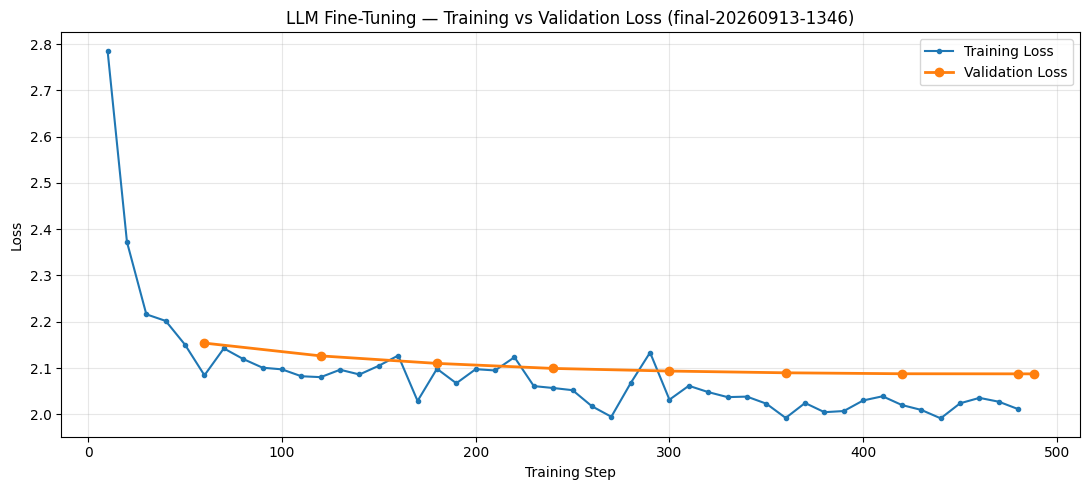

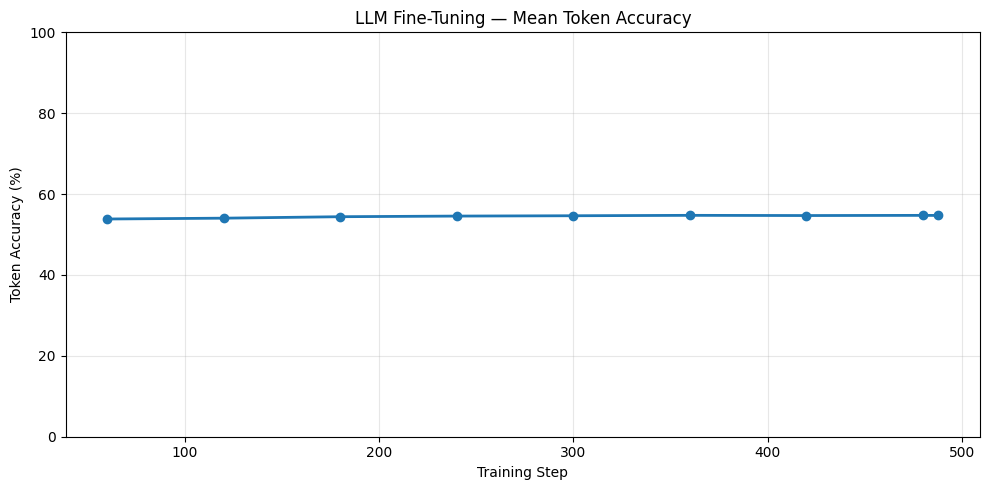

eval_loss mínima no step 488 de 488
ATENÇÃO: ainda caindo no fim -> treinou de menos. Suba EPOCHS_TREINO_FINAL.


In [16]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(trainer.state.log_history)
df_train = df[df["loss"].notna()][["step", "loss"]] if "loss" in df else pd.DataFrame()
df_eval = df[df["eval_loss"].notna()][["step", "eval_loss"]] if "eval_loss" in df else pd.DataFrame()

plt.figure(figsize=(11, 5))
if len(df_train):
    plt.plot(df_train["step"], df_train["loss"], marker="o", markersize=3,
             label="Training Loss")
if len(df_eval):
    plt.plot(df_eval["step"], df_eval["eval_loss"], marker="o", linewidth=2,
             label="Validation Loss")
plt.title(f"LLM Fine-Tuning — Training vs Validation Loss ({RUN_ID})")
plt.xlabel("Training Step"); plt.ylabel("Loss")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

if "eval_mean_token_accuracy" in df.columns:
    df_acc = df[df["eval_mean_token_accuracy"].notna()]
    if len(df_acc):
        plt.figure(figsize=(10, 5))
        plt.plot(df_acc["step"], df_acc["eval_mean_token_accuracy"] * 100,
                 marker="o", linewidth=2)
        plt.title("LLM Fine-Tuning — Mean Token Accuracy")
        plt.xlabel("Training Step"); plt.ylabel("Token Accuracy (%)")
        plt.ylim(0, 100); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

if len(df_eval):
    i_min = df_eval["eval_loss"].idxmin()
    passo_min, ultimo = df_eval.loc[i_min, "step"], df_eval["step"].max()
    print(f"eval_loss mínima no step {passo_min} de {ultimo}")
    if passo_min == ultimo:
        print("ATENÇÃO: ainda caindo no fim -> treinou de menos. Suba EPOCHS_TREINO_FINAL.")
    elif passo_min <= ultimo * 0.3:
        print("ATENÇÃO: mínimo cedo demais -> overfit. Aperte os filtros no preprocessamento.")
    else:
        print("OK — mínimo visível no meio da curva.")

## 9. Avaliação final — base vs. fine-tuned

O `test.jsonl` inteiro, mesmo conjunto e mesmo prompt para os dois modelos. O
"modelo base" é o **mesmo objeto** com o adapter desligado, então a comparação é
exata: qualquer diferença veio do treino.

In [17]:
# KV cache ligado e gradient checkpointing desligado antes de qualquer geração:
# sem isso o generate() roda ordens de magnitude mais lento do que precisaria.
modelo_peft.config.use_cache = True
try:
    modelo_peft.gradient_checkpointing_disable()
except Exception:
    pass
modelo_peft.eval()

print(f"Avaliando {len(test_dataset_full)} exemplos de test.jsonl...")
ft_test = token_accuracy(modelo_peft, test_dataset_full)
with modelo_peft.disable_adapter():
    base_test = token_accuracy(modelo_peft, test_dataset_full)

delta = (ft_test["mean_token_accuracy"] - base_test["mean_token_accuracy"]) * 100
print("\n" + "=" * 64)
print("MÉTRICAS FINAIS — LLM FINE-TUNING")
print("=" * 64)
print(f"mean_token_accuracy  base {base_test['mean_token_accuracy']*100:6.2f}%"
      f"  ->  fine-tuned {ft_test['mean_token_accuracy']*100:6.2f}%   ({delta:+.2f} pp)")
print(f"perplexidade         base {base_test['perplexidade']:6.2f} "
      f"  ->  fine-tuned {ft_test['perplexidade']:6.2f}")
print(f"treino               {WALL_CLOCK_MIN:.1f} min")
print("=" * 64)
print("\nNota para o relatório: mean_token_accuracy mede o quanto a REDAÇÃO do")
print("gabarito é previsível sob teacher forcing, não se a resposta está")
print("clinicamente correta. Ela penaliza sinônimo e paráfrase corretos.")

resultados_finais = {
    "run_id": RUN_ID, "modelo": MODEL_ID,
    "wall_clock_treino_min": round(WALL_CLOCK_MIN, 1),
    "n_test": len(test_dataset_full),
    "token_accuracy": {
        "base": round(base_test["mean_token_accuracy"], 4),
        "fine_tuned": round(ft_test["mean_token_accuracy"], 4),
        "ganho_pp": round(delta, 2),
        "baseline_validation": round(BASELINE_ACC, 4),
    },
    "perplexidade": {"base": round(base_test["perplexidade"], 2),
                     "fine_tuned": round(ft_test["perplexidade"], 2)},
    "eval_loss_min": float(df_eval["eval_loss"].min()) if len(df_eval) else None,
}
with open(os.path.join(ADAPTER_DIR, "resultados.json"), "w", encoding="utf-8") as f:
    json.dump(resultados_finais, f, ensure_ascii=False, indent=2)
print("\nSalvo em", os.path.join(ADAPTER_DIR, "resultados.json"))

Avaliando 487 exemplos de test.jsonl...

MÉTRICAS FINAIS — LLM FINE-TUNING
mean_token_accuracy  base  49.94%  ->  fine-tuned  55.48%   (+5.55 pp)
perplexidade         base  16.48   ->  fine-tuned   7.71
treino               45.6 min

Nota para o relatório: mean_token_accuracy mede o quanto a REDAÇÃO do
gabarito é previsível sob teacher forcing, não se a resposta está
clinicamente correta. Ela penaliza sinônimo e paráfrase corretos.

Salvo em /content/drive/MyDrive/Colab Notebooks/FIAP - Tech 3/assistente-medico-v3-adapter/resultados.json


### Banco de perguntas — inspeção qualitativa

Geração **greedy** (`do_sample=False`) e com o **mesmo `SYSTEM_PROMPT` do treino**.
A versão anterior usava `do_sample=True, temperature=0.3` sem seed, o que fazia
duas execuções do mesmo modelo darem respostas diferentes — e um system prompt
completamente diferente do de treino.

In [19]:
perguntas_avaliacao = [
    {"id": 1,  "categoria": "Conhecimento geral", "pergunta": "O que é hipertensão arterial e quais são os principais fatores de risco?"},
    {"id": 2,  "categoria": "Conhecimento geral", "pergunta": "O que é diabetes mellitus tipo 2 e quais são seus principais fatores de risco?"},
    {"id": 3,  "categoria": "Conhecimento geral", "pergunta": "Qual é a diferença entre uma infecção viral e uma infecção bacteriana?"},
    {"id": 4,  "categoria": "Conhecimento geral", "pergunta": "O que é anemia e quais são algumas de suas causas mais comuns?"},
    {"id": 5,  "categoria": "Conhecimento geral", "pergunta": "Qual é a função da hemoglobina no organismo?"},
    {"id": 6,  "categoria": "Saúde da mulher", "pergunta": "O que é a síndrome dos ovários policísticos (SOP) e quais são suas principais características?"},
    {"id": 7,  "categoria": "Saúde da mulher", "pergunta": "Quais são alguns sinais e sintomas que podem estar associados à síndrome dos ovários policísticos?"},
    {"id": 8,  "categoria": "Saúde da mulher", "pergunta": "A síndrome dos ovários policísticos pode afetar a fertilidade? Explique."},
    {"id": 9,  "categoria": "Saúde da mulher", "pergunta": "Qual é a relação entre resistência à insulina e síndrome dos ovários policísticos?"},
    {"id": 10, "categoria": "Saúde da mulher", "pergunta": "Quais exames podem ser utilizados na investigação clínica de uma paciente com suspeita de síndrome dos ovários policísticos?"},
    {"id": 11, "categoria": "Sintomas", "pergunta": "Quais podem ser algumas causas de dor de cabeça frequente?"},
    {"id": 12, "categoria": "Sintomas", "pergunta": "Quais podem ser algumas causas de fadiga persistente?"},
    {"id": 13, "categoria": "Sintomas", "pergunta": "Quais são algumas causas possíveis de dor abdominal?"},
    {"id": 14, "categoria": "Sintomas", "pergunta": "Quais sinais associados à dor no peito podem indicar uma situação que necessita de atendimento médico imediato?"},
    {"id": 15, "categoria": "Sintomas", "pergunta": "Quais podem ser algumas causas de tontura?"},
    {"id": 16, "categoria": "Raciocínio médico", "pergunta": "8 dias fiz cirurgia da apendicite, sinto falta de apetites e diarreia, é normal?"},
    {"id": 17, "categoria": "Prevenção", "pergunta": "Boa noite! Tenho membrana epirretiniana tenho chance de cura após cirurgia?"},
    {"id": 18, "categoria": "Prevenção", "pergunta": "Tenho alergia a dorflex, posso tomar nimesulida?"},
    {"id": 19, "categoria": "Sintomas", "pergunta": "sem sintomas nenhum, em repouso meu coração chega a 130 bpm, tenho 17 anos, colesterol alto e obesidade, seria uma questão emocional?"},
    {"id": 20, "categoria": "Sintomas", "pergunta": "Há um pouco mais de 1 ano comecei a ficar com falta de ar e dores do peito, fui em vários pneumologistas com suspeita de asma e vários exames deram normais. Não sinto melhora com nenhuma bombinha de asma. Li sobre disturbíos no nervo vago causarem sintomas semelhantes. É uma possibilidade?"},
]

@torch.no_grad()
def gerar_lote(model, perguntas, max_new_tokens=300, batch_size=8):
    model.eval()
    lado = tokenizer.padding_side
    tokenizer.padding_side = "left"          # obrigatório para geração em lote
    saidas = []
    for ini in range(0, len(perguntas), batch_size):
        lote = perguntas[ini:ini + batch_size]
        textos = [tokenizer.apply_chat_template(
            [{"role": "system", "content": SYSTEM_PROMPT},
             {"role": "user",   "content": p}],
            tokenize=False, add_generation_prompt=True) for p in lote]
        enc = tokenizer(textos, return_tensors="pt", padding=True,
                        add_special_tokens=False).to(model.device)
        out = model.generate(**enc, max_new_tokens=max_new_tokens,
                             do_sample=False,             # determinístico
                             repetition_penalty=1.05,
                             pad_token_id=tokenizer.pad_token_id,
                             eos_token_id=tokenizer.eos_token_id)
        for k in range(len(lote)):
            saidas.append(tokenizer.decode(out[k, enc["input_ids"].shape[1]:],
                                           skip_special_tokens=True).strip())
        print(f"  {len(saidas)}/{len(perguntas)}", end="\r")
    tokenizer.padding_side = lado
    return saidas

perguntas = [it["pergunta"] for it in perguntas_avaliacao]
print("Gerando com o fine-tuned...")
resp_ft = gerar_lote(modelo_peft, perguntas)
print("\nGerando com o base (adapter desligado)...")
with modelo_peft.disable_adapter():
    resp_base = gerar_lote(modelo_peft, perguntas)

df_avaliacao = pd.DataFrame([
    {"id": it["id"], "categoria": it["categoria"], "pergunta": it["pergunta"],
     "resposta_fine_tuned": a, "resposta_base": b}
    for it, a, b in zip(perguntas_avaliacao, resp_ft, resp_base)
])
df_avaliacao.to_csv(os.path.join(ADAPTER_DIR, "avaliacao_llm_finetuned.csv"),
                    index=False, encoding="utf-8-sig")
print("\nAvaliação concluída.")
display(df_avaliacao[["id", "categoria", "pergunta"]])

Gerando com o fine-tuned...
  20/20
Gerando com o base (adapter desligado)...

Avaliação concluída.


,id,categoria,pergunta
0,1,Conhecimento geral,O que é hipertensão arterial e quais são os pr...
1,2,Conhecimento geral,O que é diabetes mellitus tipo 2 e quais são s...
2,3,Conhecimento geral,Qual é a diferença entre uma infecção viral e ...
3,4,Conhecimento geral,O que é anemia e quais são algumas de suas cau...
4,5,Conhecimento geral,Qual é a função da hemoglobina no organismo?
5,6,Saúde da mulher,O que é a síndrome dos ovários policísticos (S...
6,7,Saúde da mulher,Quais são alguns sinais e sintomas que podem e...
7,8,Saúde da mulher,A síndrome dos ovários policísticos pode afeta...
8,9,Saúde da mulher,Qual é a relação entre resistência à insulina ...
9,10,Saúde da mulher,Quais exames podem ser utilizados na investiga...


In [20]:
# Leitura manual lado a lado. Procure: saudação de fórum, caixa alta,
# telefone/consultório, e se a resposta fecha sozinha (EOS) em vez de cortar.
for _, linha in df_avaliacao.iterrows():
    print("=" * 100)
    print(f"ID: {linha['id']} | Categoria: {linha['categoria']}")
    print(f"\nPERGUNTA:\n{linha['pergunta']}")
    print(f"\n--- FINE-TUNED ---\n{linha['resposta_fine_tuned']}")
    print(f"\n--- BASE ---\n{linha['resposta_base']}")
    print()

ID: 1 | Categoria: Conhecimento geral

PERGUNTA:
O que é hipertensão arterial e quais são os principais fatores de risco?

--- FINE-TUNED ---
A hipertensão arterial é uma doença crônica caracterizada por pressão arterial elevada. O ideal é que o paciente seja acompanhado por um médico para controle da pressão arterial e evitar complicações.

--- BASE ---
A hipertensão arterial, também conhecida como pressão alta arterial, é uma condição em que o fluxo sanguíneo através das artérias é mais forte do que o normal. Isso ocorre porque as paredes dos vasos sanguíneos estão mais rígidas e o coração tem que trabalhar mais para bombear sangue.

Os principais fatores de risco para a hipertensão incluem:

1. Idade: A probabilidade de desenvolver hipertensão aumenta com a idade.
2. Gênero: Mulheres têm maior probabilidade de desenvolver hipertensão após a menopausa.
3. Herança: A hipertensão pode ser hereditária.
4. Obesidade ou excesso de peso: Pessoas com um IMC alto têm maior risco.
5. Exposiçã

## 10. (Opcional) BERTScore em PT-BR

`mean_token_accuracy` penaliza sinônimo e paráfrase corretos — ela mede redação,
não conteúdo. O BERTScore compara **significado** em vez de token exato, roda
local na GPU (sem API, sem custo) e é métrica padrão de literatura.

É a forma honesta de reportar um número na faixa de 70–90% sem maquiar nada:
basta declarar qual métrica está sendo usada. Deixe `RODAR_BERTSCORE = True` para
executar — leva ~3 min.

In [26]:
RODAR_BERTSCORE = True

if RODAR_BERTSCORE:
    !pip install -q bert-score
    from bert_score import score as bert_score
    import bert_score.utils as bsu

    # --- patch: BERTimbau não declara model_max_length no tokenizer_config.
    # O transformers preenche com int(1e30) e o tokenizers (Rust) estoura
    # em enable_truncation -> OverflowError: int too big to convert.
    MAXLEN_BERT = 512
    _orig_sent_encode = bsu.sent_encode

    def _sent_encode_fixed(tokenizer, sent):
        if tokenizer.model_max_length is None or tokenizer.model_max_length > 100_000:
            tokenizer.model_max_length = MAXLEN_BERT
        return _orig_sent_encode(tokenizer, sent)

    bsu.sent_encode = _sent_encode_fixed
    print("patch sent_encode aplicado:", bsu.sent_encode is _sent_encode_fixed)
    # --- fim do patch

    N_BERT = 150
    idx = random.Random(SEED).sample(range(len(test_raw)), min(N_BERT, len(test_raw)))
    itens = [test_raw[i] for i in idx]
    refs = [it["saida"] for it in itens]
    perg = [it["entrada"] for it in itens]

    print("Gerando respostas para o BERTScore...")
    cand_ft = gerar_lote(modelo_peft, perg, max_new_tokens=260)
    with modelo_peft.disable_adapter():
        cand_base = gerar_lote(modelo_peft, perg, max_new_tokens=260)

    MODELO_BERT = "neuralmind/bert-base-portuguese-cased"
    _, _, f1_ft = bert_score(cand_ft, refs, model_type=MODELO_BERT,
                             num_layers=9, lang="pt", verbose=False)
    _, _, f1_base = bert_score(cand_base, refs, model_type=MODELO_BERT,
                               num_layers=9, lang="pt", verbose=False)

    print("\n" + "=" * 64)
    print(f"BERTScore-F1 (PT-BR, n={len(refs)})")
    print(f"  base       : {f1_base.mean().item()*100:6.2f}%")
    print(f"  fine-tuned : {f1_ft.mean().item()*100:6.2f}%")
    print(f"  ganho      : {(f1_ft.mean()-f1_base.mean()).item()*100:+6.2f} pp")
    print("=" * 64)

    resultados_finais["bertscore_f1"] = {
        "n": len(refs), "modelo_avaliador": MODELO_BERT,
        "base": round(f1_base.mean().item(), 4),
        "fine_tuned": round(f1_ft.mean().item(), 4),
    }
    with open(os.path.join(ADAPTER_DIR, "resultados.json"), "w", encoding="utf-8") as f:
        json.dump(resultados_finais, f, ensure_ascii=False, indent=2)
else:
    print("BERTScore desligado. Ligue RODAR_BERTSCORE = True para executar.")

patch sent_encode aplicado: True
Gerando respostas para o BERTScore...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



BERTScore-F1 (PT-BR, n=150)
  base       :  58.92%
  fine-tuned :  61.34%
  ganho      :  +2.42 pp
